In [49]:
import requests
import pandas as pd



In [50]:
import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")

print(API_KEY is not None)

True


In [51]:
url = f"https://api.census.gov/data/2024/acs/acs5?get=NAME,B01001_001E&for=county:*&in=state:37&key={API_KEY}"

In [52]:
response = requests.get(url)

print(response.status_code)

200


In [53]:
data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

df.head()

,NAME,B01001_001E,state,county
0,"Alamance County, North Carolina",176893,37,001
1,"Alexander County, North Carolina",36412,37,003
2,"Alleghany County, North Carolina",11174,37,005
3,"Anson County, North Carolina",22289,37,007
4,"Ashe County, North Carolina",26950,37,009


In [54]:
## Research Question

How are poverty, unemployment, age, education, and housing costs related to median household income across North Carolina counties?

Object `counties` not found.


### Poverty - B17001_002E

This variable may be useful because counties with more people living in poverty may also have lower median household incomes.

### Unemployment - B23025_005E

#This variable may be useful because unemployment can affect how much income households in a county earn.

### Median Gross Rent - B25064_001E

#This variable may be useful because rent helps show the cost of housing in a county and may be related to household income.

### Median Age - B01002_001E

#This variable may be useful because counties with different age groups may have different employment and income levels.

### High School Diploma - B15003_017E

#This variable may be useful because education level may be related to the types of jobs people can get and how much income they earn.

In [55]:
variables = ",".join([
    "NAME",
    "B01001_001E",     # Total population
    "B19013_001E",     # Median household income
    "B25077_001E",     # Median home value
    "B15003_022E",     # Bachelor's degree count
    "B17001_002E",     # Below poverty level
    "B23025_005E",     # Unemployed
    "B25064_001E",     # Median gross rent
    "B01002_001E",     # Median age
    "B15003_017E"      # High school diploma
])

url = f"https://api.census.gov/data/2024/acs/acs5?get={variables}&for=county:*&in=state:37&key={API_KEY}"

response = requests.get(url)

data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

df.head()

,NAME,B01001_001E,B19013_001E,B25077_001E,B15003_022E,B17001_002E,B23025_005E,B25064_001E,B01002_001E,B15003_017E,state,county
0,"Alamance County, North Carolina",176893,65651,241500,22917,22876,4544,1064,38.9,27269,37,001
1,"Alexander County, North Carolina",36412,65354,211800,3022,4357,857,764,43.8,8325,37,003
2,"Alleghany County, North Carolina",11174,47172,214800,1374,1770,169,675,52.6,2308,37,005
3,"Anson County, North Carolina",22289,47302,148600,1156,4483,524,814,41.9,5932,37,007
4,"Ashe County, North Carolina",26950,56866,243100,3624,3590,585,859,49.8,5572,37,009


In [56]:
df.to_csv("census_data.csv", index=False)

In [57]:
df.head()

,NAME,B01001_001E,B19013_001E,B25077_001E,B15003_022E,B17001_002E,B23025_005E,B25064_001E,B01002_001E,B15003_017E,state,county
0,"Alamance County, North Carolina",176893,65651,241500,22917,22876,4544,1064,38.9,27269,37,001
1,"Alexander County, North Carolina",36412,65354,211800,3022,4357,857,764,43.8,8325,37,003
2,"Alleghany County, North Carolina",11174,47172,214800,1374,1770,169,675,52.6,2308,37,005
3,"Anson County, North Carolina",22289,47302,148600,1156,4483,524,814,41.9,5932,37,007
4,"Ashe County, North Carolina",26950,56866,243100,3624,3590,585,859,49.8,5572,37,009


In [58]:
df.dtypes

NAME           object
B01001_001E    object
B19013_001E    object
B25077_001E    object
B15003_022E    object
B17001_002E    object
B23025_005E    object
B25064_001E    object
B01002_001E    object
B15003_017E    object
state          object
county         object
dtype: object

In [59]:
df.isnull().sum()

NAME           0
B01001_001E    0
B19013_001E    0
B25077_001E    0
B15003_022E    0
B17001_002E    0
B23025_005E    0
B25064_001E    0
B01002_001E    0
B15003_017E    0
state          0
county         0
dtype: int64

In [60]:
df.columns

Index(['NAME', 'B01001_001E', 'B19013_001E', 'B25077_001E', 'B15003_022E',
       'B17001_002E', 'B23025_005E', 'B25064_001E', 'B01002_001E',
       'B15003_017E', 'state', 'county'],
      dtype='object')

In [61]:
numeric_cols = [
    "B01001_001E",
    "B19013_001E",
    "B25077_001E",
    "B15003_022E",
    "B17001_002E",
    "B23025_005E",
    "B25064_001E",
    "B01002_001E",
    "B15003_017E"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")



## Data Cleaning and Preparation

I converted the Census variables into numeric values so they could be analyzed correctly. I also checked for missing values and replaced special Census missing-value codes when needed.

Because North Carolina counties have different population sizes, I standardized poverty, unemployment, bachelor's degree attainment, and high school attainment per 1,000 residents. This makes the counties easier to compare.

In [62]:
df.dtypes

NAME            object
B01001_001E      int64
B19013_001E      int64
B25077_001E      int64
B15003_022E      int64
B17001_002E      int64
B23025_005E      int64
B25064_001E      int64
B01002_001E    float64
B15003_017E      int64
state           object
county          object
dtype: object

In [63]:
df = df.rename(columns={
    "NAME": "County",
    "B01001_001E": "Total_Population",
    "B19013_001E": "Median_Income",
    "B25077_001E": "Median_Home_Value",
    "B15003_022E": "Bachelors_Count",
    "B17001_002E": "Below_Poverty",
    "B23025_005E": "Unemployed",
    "B25064_001E": "Median_Rent",
    "B01002_001E": "Median_Age",
    "B15003_017E": "High_School_Count"
})

df.head()

,County,Total_Population,Median_Income,Median_Home_Value,Bachelors_Count,Below_Poverty,Unemployed,Median_Rent,Median_Age,High_School_Count,state,county
0,"Alamance County, North Carolina",176893,65651,241500,22917,22876,4544,1064,38.9,27269,37,001
1,"Alexander County, North Carolina",36412,65354,211800,3022,4357,857,764,43.8,8325,37,003
2,"Alleghany County, North Carolina",11174,47172,214800,1374,1770,169,675,52.6,2308,37,005
3,"Anson County, North Carolina",22289,47302,148600,1156,4483,524,814,41.9,5932,37,007
4,"Ashe County, North Carolina",26950,56866,243100,3624,3590,585,859,49.8,5572,37,009


In [64]:
df.isnull().sum()

County               0
Total_Population     0
Median_Income        0
Median_Home_Value    0
Bachelors_Count      0
Below_Poverty        0
Unemployed           0
Median_Rent          0
Median_Age           0
High_School_Count    0
state                0
county               0
dtype: int64

In [65]:
df = df.replace({
    -666666666: pd.NA,
    -999999999: pd.NA,
    -888888888: pd.NA,
    -555555555: pd.NA,
    -333333333: pd.NA,
    -222222222: pd.NA
})

In [66]:
df.isnull().sum()

County               0
Total_Population     0
Median_Income        0
Median_Home_Value    0
Bachelors_Count      0
Below_Poverty        0
Unemployed           0
Median_Rent          0
Median_Age           0
High_School_Count    0
state                0
county               0
dtype: int64

In [67]:
df["Poverty_per_1000"] = (
    df["Below_Poverty"] / df["Total_Population"]
) * 1000

df["Unemployed_per_1000"] = (
    df["Unemployed"] / df["Total_Population"]
) * 1000

df["Bachelors_per_1000"] = (
    df["Bachelors_Count"] / df["Total_Population"]
) * 1000

df["High_School_per_1000"] = (
    df["High_School_Count"] / df["Total_Population"]
) * 1000

In [68]:
df.head()

,County,Total_Population,Median_Income,Median_Home_Value,Bachelors_Count,Below_Poverty,Unemployed,Median_Rent,Median_Age,High_School_Count,state,county,Poverty_per_1000,Unemployed_per_1000,Bachelors_per_1000,High_School_per_1000
0,"Alamance County, North Carolina",176893,65651,241500,22917,22876,4544,1064,38.9,27269,37,001,129.321115,25.687845,129.552894,154.155337
1,"Alexander County, North Carolina",36412,65354,211800,3022,4357,857,764,43.8,8325,37,003,119.658354,23.536197,82.994617,228.633418
2,"Alleghany County, North Carolina",11174,47172,214800,1374,1770,169,675,52.6,2308,37,005,158.403437,15.124396,122.964024,206.550922
3,"Anson County, North Carolina",22289,47302,148600,1156,4483,524,814,41.9,5932,37,007,201.130603,23.509354,51.864148,266.140249
4,"Ashe County, North Carolina",26950,56866,243100,3624,3590,585,859,49.8,5572,37,009,133.209647,21.706865,134.471243,206.753247


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   County                100 non-null    object 
 1   Total_Population      100 non-null    int64  
 2   Median_Income         100 non-null    int64  
 3   Median_Home_Value     100 non-null    int64  
 4   Bachelors_Count       100 non-null    int64  
 5   Below_Poverty         100 non-null    int64  
 6   Unemployed            100 non-null    int64  
 7   Median_Rent           100 non-null    int64  
 8   Median_Age            100 non-null    float64
 9   High_School_Count     100 non-null    int64  
 10  state                 100 non-null    object 
 11  county                100 non-null    object 
 12  Poverty_per_1000      100 non-null    float64
 13  Unemployed_per_1000   100 non-null    float64
 14  Bachelors_per_1000    100 non-null    float64
 15  High_School_per_1000  10

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

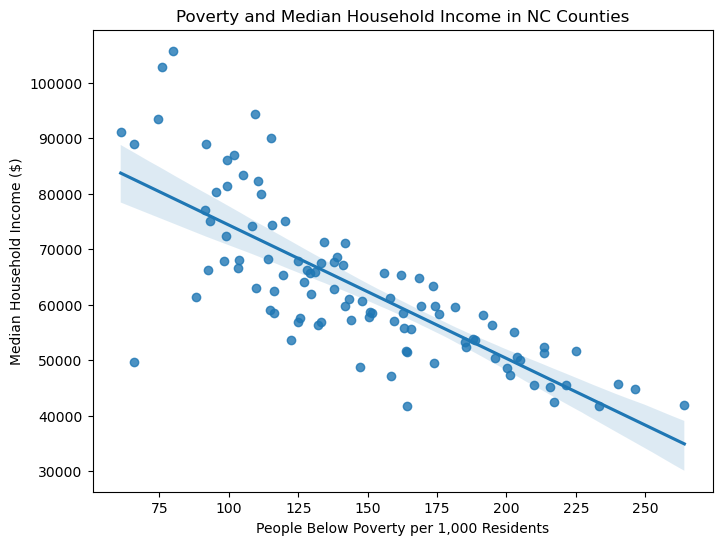

In [71]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,x="Poverty_per_1000",y="Median_Income")

plt.title("Poverty and Median Household Income in NC Counties")
plt.xlabel("People Below Poverty per 1,000 Residents")
plt.ylabel("Median Household Income ($)")

plt.show()


The scatter plot shows a clear negative relationship between poverty and median household income across North Carolina counties. As the number of people below poverty per 1,000 residents increases, median household income generally decreases. Although some counties do not follow the trend exactly, the overall pattern suggests that counties with higher levels of poverty tend to have lower household incomes.

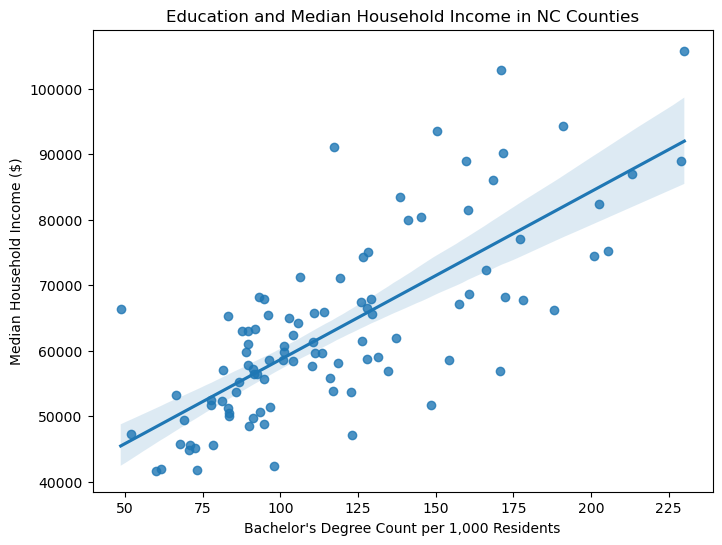

In [72]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="Bachelors_per_1000",
    y="Median_Income"
)

plt.title("Education and Median Household Income in NC Counties")
plt.xlabel("Bachelor's Degree Count per 1,000 Residents")
plt.ylabel("Median Household Income ($)")

plt.show()

The scatter plot shows a positive relationship between bachelor's degree attainment and median household income. Counties with more residents holding bachelor's degrees per 1,000 people generally have higher median household incomes. There are some counties that fall above or below the overall trend, but the relationship appears fairly strong.

Together, these visualizations suggest that education and poverty are both connected to income differences across North Carolina counties. Counties with higher levels of bachelor's degree attainment generally have higher median household incomes, while counties with higher levels of poverty generally have lower median household incomes. These results support the idea that economic conditions and educational attainment are related to household income. However, these graphs only show relationships between variables. They do not prove that poverty directly causes lower income or that earning a bachelor's degree directly causes a county's median income to increase. Other factors, such as employment opportunities, cost of living, location, and local industries, may also influence these patterns.